# Bevezetés a konvolúciós neurális hálózatokba

Az előző jegyzetben teljesen összekötött (fully connected, FC) rétegekből építettünk regressziós és osztályozó modelleket. Ebben a jegyzetben megmutatjuk, hogy nagy felbontású képeken ez a megközelítés miért válik gyorsan kezelhetetlenné, és hogyan old meg ezt a konvolúciós réteg a **lokális kapcsolódás** és a **paramétermegosztás** segítségével.

## Tanulási célok

A notebook az alábbi témákat érinti:

- a teljesen összekötött réteg paraméterszámának növekedése a képméret függvényében, és ennek összevetése egy konvolúciós réteggel;
- egy hasonló paraméterszámú MLP és egyszerű CNN összehasonlítása MNIST-en;
- a LeNet-5 architektúra megvalósítása nulláról, és tanítása Fashion-MNIST-en;
- a VGG16 blokkos felépítése és tanítása ugyanazon a feladaton;
- az eltűnő gradiens jelensége mély, konvolúciós hálókban;
- a ResNet reziduális blokkja, és hogyan oldja meg a mélység növelésével jelentkező degradációs problémát;
- egy egyszerű, egy objektumot osztályozó és bekeretező detekciós fej felépítése egy korábban tanított backbone-ra építve.


In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

# A véletlen inicializálás legyen minden futtatáskor megismételhető.
np.random.seed(42)
torch.manual_seed(42)

# Colab T4 esetén CUDA-t, más környezetben CPU-t használunk.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Használt eszköz: {device}")


Használt eszköz: cuda


In [5]:
# IDEIGLENES MEGOLDÁS: vállalati hálózaton (SSL-proxy/tanúsítványellenőrzés miatt) a letöltés
# tanúsítványhibával futhat el. Ez a cella kikapcsolja az SSL-ellenőrzést a letöltésekhez.
# Csak ezen a gépen/hálózaton szükséges - más környezetben törölhető.
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


### Közös segédfüggvények

A jegyzet minden szakasza ugyanazt a tanítási és kiértékelési ciklust használja, csak a modell, az adathalmaz és néhány hiperparaméter változik. Ezért egyszer definiáljuk:

- `count_parameters`: a tanulható paraméterek száma;
- `train_classifier`: egy tetszőleges osztályozó tanítása és tesztpontosságának mérése epochonként;
- `plot_training_curves`: a veszteség és a pontosság közös ábrázolása.

Ez ugyanaz a mintázat, mint az előző jegyzet `run_mnist_experiment` függvénye, csak általánosabb modellre alkalmazva.


In [2]:
def count_parameters(model):
    """A modell tanulható paramétereinek száma."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_classifier(name, model, optimizer, train_loader, test_loader, epochs=5, verbose=True):
    """Többosztályos osztályozó tanítása, epochonkénti veszteség és tesztpontosság mérésével."""
    criterion = nn.CrossEntropyLoss()
    model.to(device)
    losses, accuracies = [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                correct += (model(images).argmax(dim=1) == labels).sum().item()

        losses.append(running_loss / len(train_loader.dataset))
        accuracies.append(correct / len(test_loader.dataset))
        if verbose:
            print(
                f"{name:22s} | {epoch + 1}. epoch | veszteség: {losses[-1]:.4f} "
                f"| tesztpontosság: {100 * accuracies[-1]:.2f}%"
            )

    return {"loss": losses, "accuracy": accuracies}


def plot_training_curves(results_dict, title):
    """Több kísérlet tanulási görbéjének közös ábrázolása."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for name, result in results_dict.items():
        axes[0].plot(result["loss"], label=name)
        axes[1].plot(np.array(result["accuracy"]) * 100, label=name)
    axes[0].set(xlabel="epoch", ylabel="tanító veszteség", title=f"{title} – veszteség")
    axes[1].set(xlabel="epoch", ylabel="tesztpontosság (%)", title=f"{title} – pontosság")
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend()
    plt.tight_layout()
    plt.show()


---

# 1. Miért nem elég a teljesen összekötött réteg nagy képekhez?

**Valós példa – AEB előretekintő kamera.** Egy vészfékrásegítő rendszer kamerája jellemzően legalább $720\times1280$ felbontású, színes ($3$ csatornás) képkockákat szolgáltat. Egyetlen ilyen kép $720\cdot1280\cdot3\approx2{,}76$ millió értéket tartalmaz.

Az előző jegyzet MNIST-modellje egy $28\times28\times1=784$ elemű, lapított vektort kapott, és az első `nn.Linear(784, 128)` réteg is már 100 ezer feletti paramétert igényelt. Egy teljesen összekötött első réteg egy valódi kameraképen minden egyes bemeneti pixelhez külön súlyt rendelne minden egyes rejtett neuronhoz – ez a paraméterszám a képmérettel **négyzetesen** nő.

A konvolúciós réteg két, egymással összefüggő ötlettel kerüli ezt el:

- **lokális kapcsolódás:** egy kimeneti érték csak egy kis, szomszédos pixelablakból (receptív mezőből) számít, nem a teljes képből;
- **paramegosztás:** ugyanazt a kis magot (kernelt) csúsztatjuk végig a teljes képen, ezért a mag mérete a képmérettől függetlenül rögzített.

Először számszerűsítjük ezt a különbséget.


Képméret |   FC réteg paraméterei | Konv. réteg paraméterei
      28 |                602,368 |                  7,168
      64 |              3,145,984 |                  7,168
     128 |             12,583,168 |                  7,168
     224 |             38,535,424 |                  7,168
     512 |            201,326,848 |                  7,168
    1024 |            805,306,624 |                  7,168


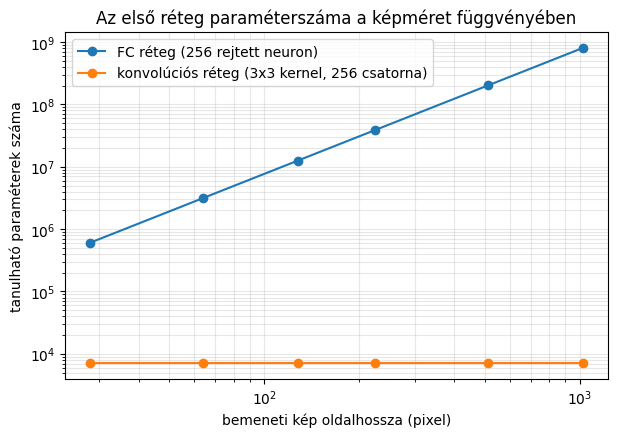

In [3]:
def fc_first_layer_params(image_side, in_channels=3, hidden_units=256):
    """Egy (H, H, C) kép -> hidden_units rejtett neuron teljesen összekötött réteg paraméterszáma."""
    input_size = image_side * image_side * in_channels
    return input_size * hidden_units + hidden_units


def conv_layer_params(kernel_size=3, in_channels=3, out_channels=256):
    """Egy konvolúciós réteg paraméterszáma – független a képmérettől."""
    return kernel_size * kernel_size * in_channels * out_channels + out_channels


image_sides = np.array([28, 64, 128, 224, 512, 1024])
fc_params = np.array([fc_first_layer_params(side) for side in image_sides])
conv_params = np.array([conv_layer_params() for _ in image_sides])

print("Képméret |   FC réteg paraméterei | Konv. réteg paraméterei")
for side, fc_count, conv_count in zip(image_sides, fc_params, conv_params):
    print(f"{side:8d} | {fc_count:22,d} | {conv_count:22,d}")

plt.figure(figsize=(7, 4.5))
plt.plot(image_sides, fc_params, "o-", label="FC réteg (256 rejtett neuron)")
plt.plot(image_sides, conv_params, "o-", label="konvolúciós réteg (3x3 kernel, 256 csatorna)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("bemeneti kép oldalhossza (pixel)")
plt.ylabel("tanulható paraméterek száma")
plt.title("Az első réteg paraméterszáma a képméret függvényében")
plt.grid(alpha=0.3, which="both")
plt.legend()
plt.show()


A teljesen összekötött réteg paraméterszáma a képméret négyzetével nő, míg a konvolúciós rétegé állandó marad, mert ugyanazt a kis kernelt csúsztatjuk végig a képen. Egy $1024\times1024$-es képnél ez már több nagyságrendnyi különbséget jelent.

Ez nem csupán memóriakérdés. Kevesebb paraméter kevesebb tanítómintából is jól illeszthető, és a paramegosztás miatt a konvolúciós réteg **eltolás-ekvivariáns**: ha a bemeneti kép egy mintázata eltolódik, a kimeneti aktivációs térkép ugyanúgy eltolódik, a felismert mintázat típusa nem változik.

## 1.1 Hasonló paraméterszámú MLP és CNN összehasonlítása MNIST-en

Az előző jegyzet MNIST-modellje egy `Linear(784, 128)` és egy `Linear(128, 10)` rétegből állt, összesen kb. 101 770 tanulható paraméterrel, és 5 epoch alatt kb. 93%-os tesztpontosságot ért el egyszerű SGD-vel.

Most egy hasonló nagyságrendű paraméterszámú, de konvolúciós rétegeket használó hálót építünk, és ugyanazzal a tanítási protokollal hasonlítjuk össze a kettőt.


In [6]:
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
mnist_train_loader = DataLoader(mnist_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


def make_mlp():
    """Az előző jegyzet 784 -> 128 -> 10 architektúrája."""
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    )


def make_simple_cnn():
    """Hasonló paraméterszámú, de konvolúciós rétegekre épülő architektúra."""
    return nn.Sequential(
        nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (B, 1, 28, 28) -> (B, 16, 28, 28)
        nn.ReLU(),
        nn.MaxPool2d(2),                             # -> (B, 16, 14, 14)
        nn.Conv2d(16, 32, kernel_size=3, padding=1),  # -> (B, 32, 14, 14)
        nn.ReLU(),
        nn.MaxPool2d(2),                             # -> (B, 32, 7, 7)
        nn.Flatten(),
        nn.Linear(32 * 7 * 7, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )


torch.manual_seed(42)
mlp_model = make_mlp()
torch.manual_seed(42)
simple_cnn_model = make_simple_cnn()

print(f"MLP tanulható paraméterei:  {count_parameters(mlp_model):,d}")
print(f"CNN tanulható paraméterei:  {count_parameters(simple_cnn_model):,d}")


Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/9912422 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/28881 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/1648877 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



  0%|          | 0/4542 [00:00<?, ?it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw

MLP tanulható paraméterei:  101,770
CNN tanulható paraméterei:  105,866


MLP                    | 1. epoch | veszteség: 0.7765 | tesztpontosság: 89.14%
MLP                    | 2. epoch | veszteség: 0.3534 | tesztpontosság: 91.23%
MLP                    | 3. epoch | veszteség: 0.3042 | tesztpontosság: 92.03%
MLP                    | 4. epoch | veszteség: 0.2734 | tesztpontosság: 92.54%
MLP                    | 5. epoch | veszteség: 0.2473 | tesztpontosság: 93.25%
Egyszerű CNN           | 1. epoch | veszteség: 0.8272 | tesztpontosság: 92.42%
Egyszerű CNN           | 2. epoch | veszteség: 0.1637 | tesztpontosság: 96.14%
Egyszerű CNN           | 3. epoch | veszteség: 0.1096 | tesztpontosság: 97.00%
Egyszerű CNN           | 4. epoch | veszteség: 0.0862 | tesztpontosság: 97.71%
Egyszerű CNN           | 5. epoch | veszteség: 0.0723 | tesztpontosság: 97.84%


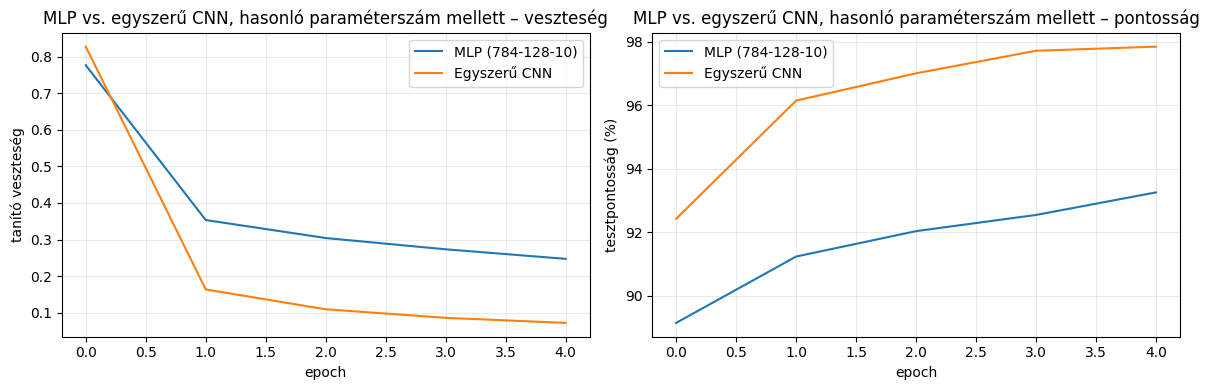

In [7]:
mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.1)
cnn_optimizer = torch.optim.SGD(simple_cnn_model.parameters(), lr=0.1)

capacity_results = {
    "MLP (784-128-10)": train_classifier(
        "MLP", mlp_model, mlp_optimizer, mnist_train_loader, mnist_test_loader, epochs=5
    ),
    "Egyszerű CNN": train_classifier(
        "Egyszerű CNN", simple_cnn_model, cnn_optimizer, mnist_train_loader, mnist_test_loader, epochs=5
    ),
}

plot_training_curves(capacity_results, "MLP vs. egyszerű CNN, hasonló paraméterszám mellett")


Hasonló paraméterszám mellett a konvolúciós háló magasabb tesztpontosságot ér el, mint a teljesen összekötött modell. Ennek oka, hogy a konvolúciós rétegek eleve olyan feltételezéssel (induktív torzítással) élnek, amely illeszkedik a képek szerkezetéhez: a közeli pixelek együtt hordoznak jelentést, és egy mintázat (pl. egy él) a kép bármely részén hasonlóan jelenik meg. Az MLP-nek ugyanezt a szerkezetet nulláról, sokkal több adatból kellene megtanulnia.

---

# 2. A LeNet-5 architektúra

A LeNet-5-öt Yann LeCun és munkatársai tervezték az 1990-es években, kézzel írott számjegyek felismerésére. Ez volt az egyik első sikeres konvolúciós háló, és a mai architektúrák is ugyanazt az alapmintát követik: **konvolúció → aktiváció → pooling**, ismételve, majd a végén néhány teljesen összekötött réteg.

| Réteg | Művelet | Kimenet alakja |
|---|---|---|
| Bemenet | – | $1\times28\times28$ |
| C1 | $5\times5$ konvolúció, 6 csatorna | $6\times28\times28$ |
| S2 | $2\times2$ átlagoló pooling | $6\times14\times14$ |
| C3 | $5\times5$ konvolúció, 16 csatorna | $16\times10\times10$ |
| S4 | $2\times2$ átlagoló pooling | $16\times5\times5$ |
| C5/F5 | lapítás + teljesen összekötött réteg | 120 |
| F6 | teljesen összekötött réteg | 84 |
| Kimenet | teljesen összekötött réteg | 10 |

**Valós példa – közúti jelzőtábla-osztályozás.** Egy kis, alacsony felbontású ($32\times32$ körüli) képen működő, kevés paraméteres háló jó kiindulópont lehet beágyazott, korlátozott számítási kapacitású rendszereken futó, egyszerű osztályozási feladatokhoz, mint amilyen egy jelzőtábla típusának felismerése.

Ezúttal nem a hagyományos MNIST-et, hanem a nehezebb **Fashion-MNIST** adathalmazt használjuk: ugyanolyan méretű ($28\times28$, szürkeárnyalatos) képek, de ruhadarabokat ábrázolnak, és a tíz osztály vizuálisan kevésbé különül el, mint a számjegyeknél.


  0%|          | 0/26421880 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/train-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/29515 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/4422102 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to ./data/FashionMNIST/raw



  0%|          | 0/5148 [00:00<?, ?it/s]

Extracting ./data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/FashionMNIST/raw



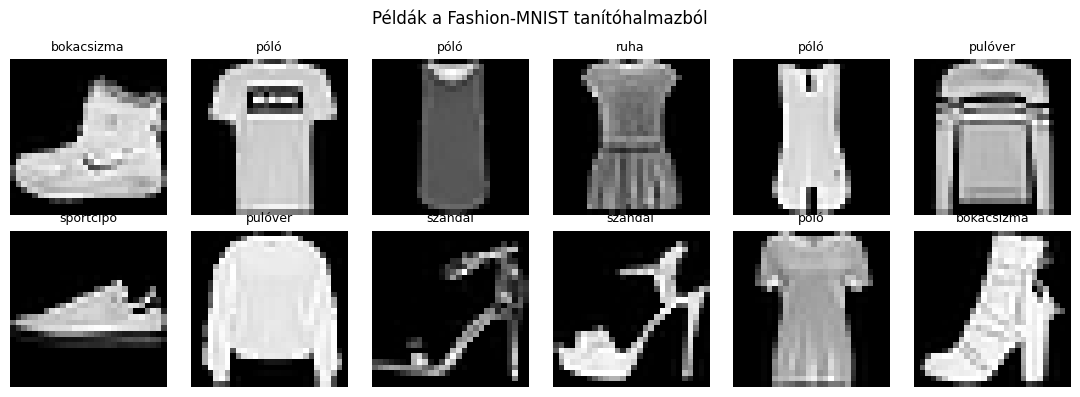

In [8]:
fashion_classes = [
    "póló", "nadrág", "pulóver", "ruha", "kabát",
    "szandál", "ing", "sportcipő", "táska", "bokacsizma",
]

fashion_train = datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
fashion_test = datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor()
)
fashion_train_loader = DataLoader(fashion_train, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
fashion_test_loader = DataLoader(fashion_test, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

fig, axes = plt.subplots(2, 6, figsize=(11, 4))
for index, axis in enumerate(axes.ravel()):
    image, label = fashion_train[index]  # (1, 28, 28), skalár
    axis.imshow(image.squeeze(0), cmap="gray")
    axis.set_title(fashion_classes[label], fontsize=9)
    axis.axis("off")
plt.suptitle("Példák a Fashion-MNIST tanítóhalmazból")
plt.tight_layout()
plt.show()


In [9]:
class LeNet5(nn.Module):
    """A klasszikus LeNet-5 architektúra, 10 osztályos kimenetre igazítva."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)   # (B, 1, 28, 28) -> (B, 6, 28, 28)
        self.pool1 = nn.AvgPool2d(2)                             # -> (B, 6, 14, 14)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)              # -> (B, 16, 10, 10)
        self.pool2 = nn.AvgPool2d(2)                             # -> (B, 16, 5, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)
        self.activation = torch.tanh  # az eredeti publikáció szerinti aktiváció

    def forward(self, x):
        x = self.activation(self.conv1(x))
        x = self.pool1(x)
        x = self.activation(self.conv2(x))
        x = self.pool2(x)
        x = x.flatten(1)              # (B, 16, 5, 5) -> (B, 400)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)            # (B, 10) logit


torch.manual_seed(42)
lenet_model = LeNet5()
print(f"LeNet-5 tanulható paraméterei: {count_parameters(lenet_model):,d}")

lenet_optimizer = torch.optim.SGD(lenet_model.parameters(), lr=0.1, momentum=0.9)
lenet_results = train_classifier(
    "LeNet-5", lenet_model, lenet_optimizer, fashion_train_loader, fashion_test_loader, epochs=8
)


LeNet-5 tanulható paraméterei: 61,706
LeNet-5                | 1. epoch | veszteség: 0.7039 | tesztpontosság: 84.11%
LeNet-5                | 2. epoch | veszteség: 0.3959 | tesztpontosság: 85.67%
LeNet-5                | 3. epoch | veszteség: 0.3480 | tesztpontosság: 86.55%
LeNet-5                | 4. epoch | veszteség: 0.3158 | tesztpontosság: 88.04%
LeNet-5                | 5. epoch | veszteség: 0.2948 | tesztpontosság: 87.77%
LeNet-5                | 6. epoch | veszteség: 0.2760 | tesztpontosság: 87.78%
LeNet-5                | 7. epoch | veszteség: 0.2618 | tesztpontosság: 87.80%
LeNet-5                | 8. epoch | veszteség: 0.2462 | tesztpontosság: 88.77%


---

# 3. A VGG16 architektúra

A VGG-hálók (Simonyan és Zisserman, 2014) központi ötlete, hogy egyetlen nagy kernel helyett **több egymást követő $3\times3$ konvolúciót** érdemes használni. Két egymás utáni $3\times3$ konvolúció ugyanakkora receptív mezőt ad, mint egy $5\times5$-ös, de kevesebb paraméterrel és két nemlineáris aktivációval.

A VGG16 blokkos felépítésű: minden blokk néhány $3\times3$ konvolúciós rétegből áll (rögzített csatornaszámmal), amit egy $2\times2$-es max-pooling zár le és megfelezi a térbeli felbontást, miközben a következő blokkban megduplázzuk a csatornaszámot:

$$
64\to64\to\text{pool}\to128\to128\to\text{pool}\to256\to256\to256\to\text{pool}\to512\to512\to512\to\text{pool}\to512\to512\to512\to\text{pool}.
$$

Az eredeti VGG16-ot $224\times224$-es ImageNet-képekre tervezték, és a konvolúciós rész után két 4096 egységű teljesen összekötött réteg következik, összesen kb. 138 millió paraméterrel. Ebben a jegyzetben ugyanazt a konvolúciós blokkstruktúrát használjuk, de:

- a bemenetet $32\times32$-es szürkeárnyalatos képre igazítjuk (Fashion-MNIST, átméretezve);
- a klasszifikáló fejet lényegesen kisebbre vesszük, mert a 4096 egységű rétegek erre a kis feladatra feleslegesen sok paramétert és számítást jelentenének.

Ez a leegyszerűsítés megőrzi a VGG16 lényegét (mély, kis kernelű konvolúciós blokkok), miközben az órai keretek között is tanítható marad.


In [13]:
VGG16_CONFIG = [64, 64, "M", 128, 128, "M", 256, 256, 256, "M", 512, 512, 512, "M", 512, 512, 512, "M"]


def make_vgg_feature_layers(config, in_channels=1):
    """A VGG16 konvolúciós blokkjai a megadott konfiguráció alapján."""
    layers = []
    channels = in_channels
    for item in config:
        if item == "M":
            layers.append(nn.MaxPool2d(kernel_size=2))
        else:
            layers += [
                nn.Conv2d(channels, item, kernel_size=3, padding=1),
                nn.BatchNorm2d(item),
                nn.ReLU(inplace=True),
            ]
            channels = item
    return nn.Sequential(*layers)


class VGG16Small(nn.Module):
    """A VGG16 konvolúciós blokkjai, kis bemenethez igazított, kompakt klasszifikáló fejjel."""

    def __init__(self, num_classes=10, input_side=32):
        super().__init__()
        self.features = make_vgg_feature_layers(VGG16_CONFIG, in_channels=1)
        reduced_side = input_side // (2 ** VGG16_CONFIG.count("M"))  # 5 pooling -> 32 / 32 = 1
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * reduced_side * reduced_side, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


torch.manual_seed(42)
vgg_model = VGG16Small()
print(f"VGG16 (kompakt fejjel) tanulható paraméterei: {count_parameters(vgg_model):,d}")


VGG16 (kompakt fejjel) tanulható paraméterei: 14,855,882


A VGG16-nak jóval több rétege és paramétere van, mint a LeNet-5-nek, ezért egy epoch is tovább tart. A tisztességes összehasonlítás érdekében ugyanazt a teljes tanítóhalmazt és ugyanannyi epochot használjuk, mint a LeNet-5-nél – csak a felbontást méretezzük át $32\times32$-re, hogy az 5 max-pooling réteg után maradjon térbeli kiterjedés. Ez GPU-n is számottevően tovább tart, mint a LeNet-5 tanítása.


In [14]:
resize_transform = transforms.Compose([transforms.Resize(32), transforms.ToTensor()])
fashion_train_32 = datasets.FashionMNIST(root="./data", train=True, download=False, transform=resize_transform)
fashion_test_32 = datasets.FashionMNIST(root="./data", train=False, download=False, transform=resize_transform)

# A teljes tanítóhalmazt használjuk, ugyanúgy, mint a LeNet-5-nél.
vgg_train_loader = DataLoader(fashion_train_32, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
vgg_test_loader = DataLoader(fashion_test_32, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)

vgg_optimizer = torch.optim.Adam(vgg_model.parameters(), lr=1e-3)
vgg_results = train_classifier(
    "VGG16", vgg_model, vgg_optimizer, vgg_train_loader, vgg_test_loader, epochs=8
)


VGG16                  | 1. epoch | veszteség: 0.6221 | tesztpontosság: 85.95%
VGG16                  | 2. epoch | veszteség: 0.3292 | tesztpontosság: 87.07%
VGG16                  | 3. epoch | veszteség: 0.2708 | tesztpontosság: 89.73%
VGG16                  | 4. epoch | veszteség: 0.2418 | tesztpontosság: 90.51%
VGG16                  | 5. epoch | veszteség: 0.2156 | tesztpontosság: 89.94%
VGG16                  | 6. epoch | veszteség: 0.2020 | tesztpontosság: 92.31%
VGG16                  | 7. epoch | veszteség: 0.1793 | tesztpontosság: 92.47%
VGG16                  | 8. epoch | veszteség: 0.1634 | tesztpontosság: 90.93%


LeNet-5 paraméterei: 61,706  | végső tesztpontosság: 88.77%
VGG16 paraméterei:   14,855,882  | végső tesztpontosság: 90.93%


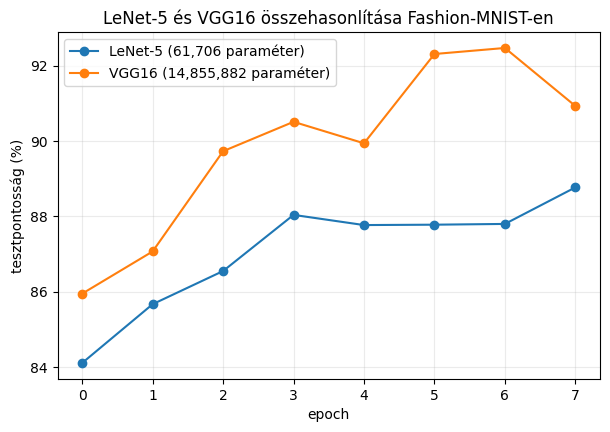

In [15]:
print(f"LeNet-5 paraméterei: {count_parameters(lenet_model):,d}  | végső tesztpontosság: {100 * lenet_results['accuracy'][-1]:.2f}%")
print(f"VGG16 paraméterei:   {count_parameters(vgg_model):,d}  | végső tesztpontosság: {100 * vgg_results['accuracy'][-1]:.2f}%")

plt.figure(figsize=(7, 4.5))
plt.plot(np.array(lenet_results["accuracy"]) * 100, "o-", label=f"LeNet-5 ({count_parameters(lenet_model):,d} paraméter)")
plt.plot(np.array(vgg_results["accuracy"]) * 100, "o-", label=f"VGG16 ({count_parameters(vgg_model):,d} paraméter)")
plt.xlabel("epoch")
plt.ylabel("tesztpontosság (%)")
plt.title("LeNet-5 és VGG16 összehasonlítása Fashion-MNIST-en")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


---

# 4. Az eltűnő gradiens jelensége

Minél több réteget rakunk egymás után, annál hosszabb szorzatláncon keresztül kell a hibát a kimenettől a legelső rétegig visszaterjeszteni. A láncszabály szerint egy korai réteg súlyának gradiense a rákövetkező rétegek deriváltjainak **szorzata**:

$$
\frac{\partial L}{\partial \mathbf{w}^{(1)}}
=\frac{\partial L}{\partial \mathbf{h}^{(N)}}
\cdot\frac{\partial \mathbf{h}^{(N)}}{\partial \mathbf{h}^{(N-1)}}
\cdots
\frac{\partial \mathbf{h}^{(2)}}{\partial \mathbf{h}^{(1)}}
\cdot\frac{\partial \mathbf{h}^{(1)}}{\partial \mathbf{w}^{(1)}}.
$$

A szigmoid és a tanh deriváltja mindenütt $1$-nél kisebb (a szigmoidé legfeljebb $0{,}25$). Ha sok ilyen, $1$-nél kisebb tényezőt szorzunk össze, a szorzat exponenciálisan kicsivé válik a mélységgel – ez az **eltűnő gradiens**. A korai rétegek gradiense elhanyagolhatóvá válik, ezért gyakorlatilag nem tanulnak tovább.

A ReLU deriváltja aktív neuronokra pontosan $1$, ezért nem szorítja szisztematikusan a szorzatot $1$ alá – ez az egyik fő oka, hogy a mély hálókban ma szinte kizárólag ReLU-alapú aktivációkat használnak. (A ReLU-nak megvan a maga hátulütője, a tartósan nulla gradiensű, „kihaló” neuronok problémája, de ez más jellegű jelenség.)

Ezt egy mesterségesen mély, egyszerű konvolúciós hálón szemléltetjük: rétegenként megmérjük a súlyok gradiensének normáját közvetlenül egyetlen visszaterjesztés után.


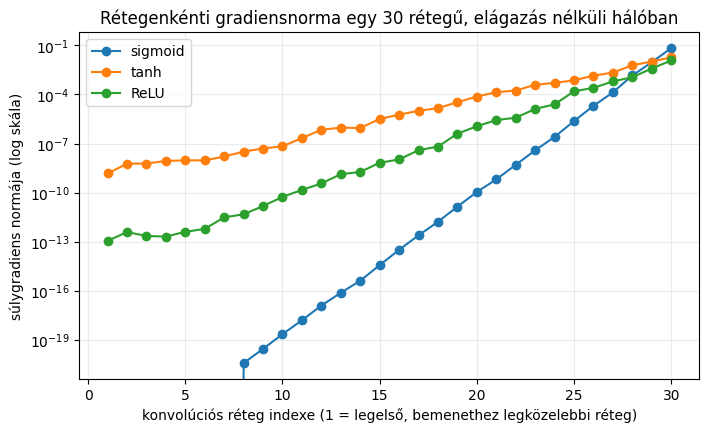

In [16]:
def build_deep_plain_cnn(depth, activation_cls, channels=16):
    """Mély, elágazás nélküli konvolúciós háló, cserélhető aktivációval."""
    layers = [nn.Conv2d(1, channels, kernel_size=3, padding=1), activation_cls()]
    for _ in range(depth - 1):
        layers += [nn.Conv2d(channels, channels, kernel_size=3, padding=1), activation_cls()]
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(channels, 10)]
    return nn.Sequential(*layers)


def layerwise_gradient_norms(model, images, labels):
    """Egyetlen forward + backward lépés után a konvolúciós rétegek súlygradiensének normája, rétegenként."""
    criterion = nn.CrossEntropyLoss()
    model.zero_grad()
    loss = criterion(model(images), labels)
    loss.backward()
    norms = [
        module.weight.grad.norm().item()
        for module in model
        if isinstance(module, nn.Conv2d)
    ]
    return norms


depth = 30
sample_images, sample_labels = next(iter(fashion_train_loader))
sample_images, sample_labels = sample_images.to(device), sample_labels.to(device)

gradient_norms_by_activation = {}
for activation_name, activation_cls in [("sigmoid", nn.Sigmoid), ("tanh", nn.Tanh), ("ReLU", nn.ReLU)]:
    torch.manual_seed(0)
    deep_model = build_deep_plain_cnn(depth, activation_cls).to(device)
    gradient_norms_by_activation[activation_name] = layerwise_gradient_norms(deep_model, sample_images, sample_labels)

plt.figure(figsize=(8, 4.5))
for activation_name, norms in gradient_norms_by_activation.items():
    plt.plot(range(1, depth + 1), norms, "o-", label=activation_name)
plt.yscale("log")
plt.xlabel("konvolúciós réteg indexe (1 = legelső, bemenethez legközelebbi réteg)")
plt.ylabel("súlygradiens normája (log skála)")
plt.title(f"Rétegenkénti gradiensnorma egy {depth} rétegű, elágazás nélküli hálóban")
plt.grid(alpha=0.25, which="both")
plt.legend()
plt.show()


A szigmoid és a tanh aktivációnál a gradiens normája a bemenethez közeli rétegeknél nagyságrendekkel kisebb, mint a kimenethez közelieknél – ez az eltűnő gradiens. A ReLU-nál a csökkenés jóval enyhébb. Ez az egyik fő ok, amiért egy sok rétegű, elágazás nélküli hálót önmagában egyre nehezebb hatékonyan tanítani, minél mélyebbre megyünk.

---

# 5. ResNet: reziduális kapcsolatok

Az eltűnő gradiens nem az egyetlen probléma, amit a mélység okoz. He és munkatársai (2015) megfigyelték, hogy egy elágazás nélküli (plain) hálót egyre több réteggel építve, egy bizonyos mélység felett a **tanítási** hiba is romlani kezd – nem csupán a tesztpontosság. Ezt **degradációs problémának** nevezték: nem (csak) túlillesztésről van szó, hanem arról, hogy a mélyebb hálót nehezebb optimalizálni.

A megoldásuk a **reziduális blokk**: a blokk bemenetét hozzáadjuk a blokk kimenetéhez, mielőtt az aktivációra kerülne sor:

$$
\mathbf{h}_{\text{out}}=\text{ReLU}\big(\mathcal{F}(\mathbf{h}_{\text{in}})+\mathbf{h}_{\text{in}}\big),
$$

ahol $\mathcal{F}$ a blokk belső rétegei (jellemzően két konvolúció batch-normalizálással). A blokknak elég csak egy kis eltérést, egy **maradékot** ($\mathcal{F}(\mathbf{h}_{\text{in}})$) megtanulnia az azonossági leképezéshez képest. Ha egy blokknak semmi hasznosat nem kell hozzátennie, könnyen megtanulhatja $\mathcal{F}(\mathbf{h}_{\text{in}})\approx\mathbf{0}$-t, és a hálón az információ és a gradiens is szabadon átfolyhat az összeadó kapcsolaton (a **skip connectionön**) keresztül. Ez egyszerre segít a degradációs probléma és az eltűnő gradiens ellen.

Az alábbi kísérletben ugyanazt az alapblokkot építjük fel skip connectionnel és anélkül, majd különböző mélységeknél hasonlítjuk össze a tanítási és teszt pontosságot.


In [17]:
class BasicBlock(nn.Module):
    """Két 3x3 konvolúció, batch-normalizálással, opcionális skip connectionnel."""

    def __init__(self, channels, use_skip=True):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)
        self.use_skip = use_skip

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.use_skip:
            out = out + x
        return F.relu(out)


class BlockNet(nn.Module):
    """Azonos felépítésű háló, amely `num_blocks` darab BasicBlockot rak egymás után."""

    def __init__(self, num_blocks, channels=16, use_skip=True, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
        )
        self.blocks = nn.Sequential(*[BasicBlock(channels, use_skip=use_skip) for _ in range(num_blocks)])
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(channels, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        return self.head(x)


# Egy BasicBlock 2 konvolúciós réteget tartalmaz, plusz a stem 1 rétege.
depths_in_blocks = [1, 4, 9, 16]
depth_experiment_results = {}

# A gyorsabb futás érdekében a tanítóhalmaz egy részhalmazát és kevesebb epochot használunk.
depth_train_subset = Subset(fashion_train, np.arange(6000))
depth_train_loader = DataLoader(depth_train_subset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

for use_skip in [False, True]:
    variant_name = "ResNet (skip)" if use_skip else "PlainNet (skip nélkül)"
    accuracies_at_depth = []
    for num_blocks in depths_in_blocks:
        torch.manual_seed(0)
        model = BlockNet(num_blocks=num_blocks, use_skip=use_skip)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        result = train_classifier(
            f"{variant_name}, {num_blocks} blokk", model, optimizer,
            depth_train_loader, fashion_test_loader, epochs=4, verbose=False,
        )
        accuracies_at_depth.append(result["accuracy"][-1])
        print(f"{variant_name:24s} | {num_blocks:2d} blokk ({2 * num_blocks + 1} réteg) | tesztpontosság: {100 * accuracies_at_depth[-1]:.2f}%")
    depth_experiment_results[variant_name] = accuracies_at_depth


PlainNet (skip nélkül)   |  1 blokk (3 réteg) | tesztpontosság: 47.78%
PlainNet (skip nélkül)   |  4 blokk (9 réteg) | tesztpontosság: 66.88%
PlainNet (skip nélkül)   |  9 blokk (19 réteg) | tesztpontosság: 70.97%
PlainNet (skip nélkül)   | 16 blokk (33 réteg) | tesztpontosság: 56.18%
ResNet (skip)            |  1 blokk (3 réteg) | tesztpontosság: 48.72%
ResNet (skip)            |  4 blokk (9 réteg) | tesztpontosság: 67.92%
ResNet (skip)            |  9 blokk (19 réteg) | tesztpontosság: 68.95%
ResNet (skip)            | 16 blokk (33 réteg) | tesztpontosság: 69.03%


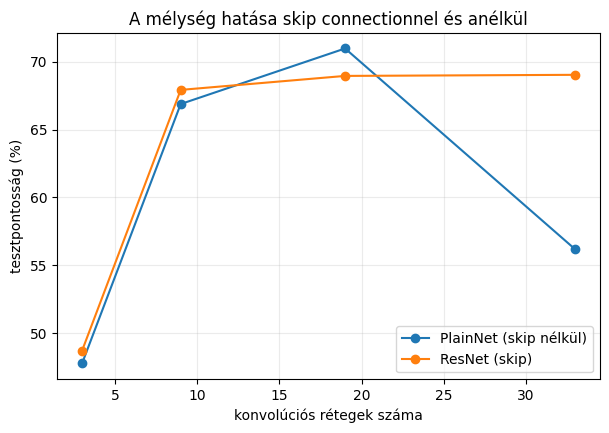

In [18]:
num_layers = [2 * blocks + 1 for blocks in depths_in_blocks]

plt.figure(figsize=(7, 4.5))
for variant_name, accuracies in depth_experiment_results.items():
    plt.plot(num_layers, np.array(accuracies) * 100, "o-", label=variant_name)
plt.xlabel("konvolúciós rétegek száma")
plt.ylabel("tesztpontosság (%)")
plt.title("A mélység hatása skip connectionnel és anélkül")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


A skip connection nélküli hálónál a mélység növelése egy ponton túl már nem javítja, hanem rontja a teljesítményt: ez a He és munkatársai által leírt degradációs jelenség kicsinyített, óra alatt bemutatható változata. A skip connectiont tartalmazó változat ugyanolyan mélységnél stabilabban, jellemzően jobb pontossággal tanítható, mert a blokkoknak elég csak egy maradékot megtanulniuk, és a gradiens szabadon átfolyhat az összeadó kapcsolatokon.

---

# 6. Bevezetés az objektumdetektálásba

Az eddigi feladat mindig **osztályozás** volt: egy kép egészéhez rendeltünk egyetlen címkét. Az **objektumdetektálás** ennél többet vár el: meg kell mondani, hogy *milyen* objektum van a képen, és *hol* helyezkedik el, jellemzően egy befoglaló téglalappal (bounding box-szal) megadva.

**Valós példa – AEB.** Egy vészfékrásegítő rendszernek nem elég tudnia, hogy „van-e jármű a képen”. Azt is meg kell becsülnie, hogy a jármű a kép mely részén, mekkora méretben látszik, hiszen ebből (a kamera geometriájának ismeretében) következtetni lehet a relatív pozícióra és a kockázatra.

A valós detektorok (pl. Faster R-CNN, YOLO, SSD) egyszerre több, különböző méretű és pozíciójú objektumot is kezelnek, rácspontonként vagy horgonydobozonként (anchor) becsülve az osztályt és a téglalapot. Ez a bevezető jegyzet ennél szándékosan egyszerűbb feladatot old meg, hogy az architektúra alapötlete átlátható maradjon:

- pontosan **egy objektum** van minden képen;
- a modellnek egyetlen osztálycímkét és egyetlen befoglaló téglalapot kell becsülnie;
- a **backbone** (jellemzőkinyerő hálózat) a korábban megismert, blokkos CNN, amelyre két, egyszerű **fej** épül: egy osztályozó és egy téglalap-regressziós fej.

Ez a felépítés – közös backbone, több feladatspecifikus fej – a modern detektorok is ugyanezt az elvet követik, csak jóval több kimenettel és rácsponttal.


## 6.1 Szintetikus egyobjektumos detekciós adathalmaz

Mivel a Fashion-MNIST önmagában nem tartalmaz elhelyezési (bounding box) címkéket, egy egyszerű szintetikus feladatot készítünk belőle: minden $28\times28$-as ruhadarab-képet egy nagyobb, $64\times64$-es fekete vászonra helyezünk, véletlenszerűen megválasztott pozícióban. A cél a ruhadarab osztálya és a befoglaló téglalapja (a vászonhoz képest, $[0,1]$-re normalizálva).


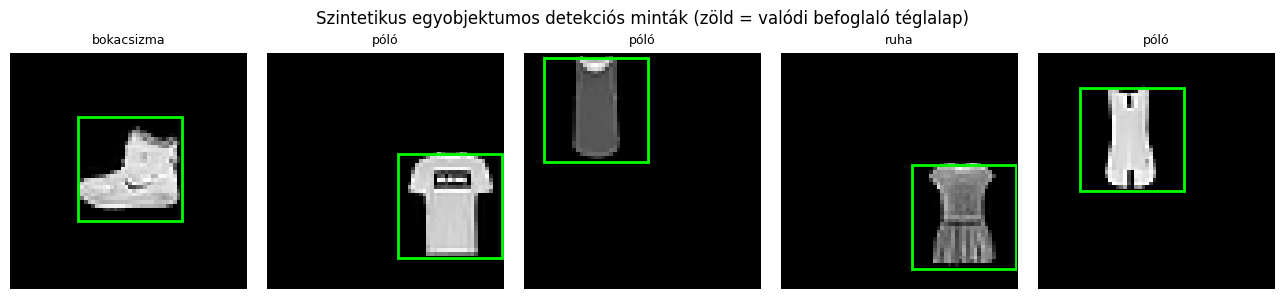

In [19]:
class SingleObjectDetectionDataset(Dataset):
    """Egyetlen Fashion-MNIST objektumot véletlen pozícióba helyez egy nagyobb vásznon."""

    CANVAS_SIZE = 64
    OBJECT_SIZE = 28

    def __init__(self, fashion_dataset, seed=0):
        self.fashion_dataset = fashion_dataset
        generator = np.random.default_rng(seed)
        max_offset = self.CANVAS_SIZE - self.OBJECT_SIZE
        self.offsets = generator.integers(0, max_offset + 1, size=(len(fashion_dataset), 2))

    def __len__(self):
        return len(self.fashion_dataset)

    def __getitem__(self, index):
        image, label = self.fashion_dataset[index]  # image: (1, 28, 28)
        top, left = self.offsets[index]

        canvas = torch.zeros(1, self.CANVAS_SIZE, self.CANVAS_SIZE)
        canvas[:, top:top + self.OBJECT_SIZE, left:left + self.OBJECT_SIZE] = image

        # Befoglaló téglalap (x_min, y_min, x_max, y_max), [0, 1]-re normalizálva.
        bbox = torch.tensor([
            left / self.CANVAS_SIZE,
            top / self.CANVAS_SIZE,
            (left + self.OBJECT_SIZE) / self.CANVAS_SIZE,
            (top + self.OBJECT_SIZE) / self.CANVAS_SIZE,
        ], dtype=torch.float32)

        return canvas, label, bbox


detection_train_dataset = SingleObjectDetectionDataset(fashion_train, seed=1)
detection_test_dataset = SingleObjectDetectionDataset(fashion_test, seed=2)

# A gyorsabb tanítás érdekében ismét egy részhalmazt használunk.
detection_train_subset = Subset(detection_train_dataset, np.arange(10000))
detection_train_loader = DataLoader(detection_train_subset, batch_size=128, shuffle=True, num_workers=2)
detection_test_loader = DataLoader(detection_test_dataset, batch_size=256, shuffle=False, num_workers=2)


def draw_sample(axis, image, label_text, bbox, color, box_label=None):
    """Egy kép megjelenítése a hozzá tartozó befoglaló téglalappal."""
    canvas_size = image.shape[-1]
    axis.imshow(image.squeeze(0), cmap="gray")
    x_min, y_min, x_max, y_max = (bbox * canvas_size).tolist()
    rectangle = patches.Rectangle(
        (x_min, y_min), x_max - x_min, y_max - y_min,
        linewidth=2, edgecolor=color, facecolor="none",
    )
    axis.add_patch(rectangle)
    if box_label:
        axis.text(x_min, max(y_min - 2, 0), box_label, color=color, fontsize=9, weight="bold")
    axis.set_title(label_text, fontsize=9)
    axis.axis("off")


fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for index, axis in enumerate(axes):
    image, label, bbox = detection_train_dataset[index]
    draw_sample(axis, image, fashion_classes[label], bbox, color="lime")
plt.suptitle("Szintetikus egyobjektumos detekciós minták (zöld = valódi befoglaló téglalap)")
plt.tight_layout()
plt.show()


## 6.2 Backbone + két fej: osztályozás és téglalap-regresszió

A modell felépítése:

1. **Backbone:** az 5. szakaszban bevezetett `BlockNet`-hez hasonló, skip connectiont tartalmazó konvolúciós háló, amely a $64\times64$-es bemenetből egyetlen jellemzővektort állít elő (globális átlagoló pooling után).
2. **Osztályozó fej:** egyetlen `Linear` réteg, amely a jellemzővektorból 10 logitot ad, ugyanúgy, mint egy sima osztályozásnál.
3. **Téglalap-regressziós fej:** egyetlen `Linear` réteg, amely 4 értéket ad ($x_{min},y_{min},x_{max},y_{max}$), majd `Sigmoid`-dal $[0,1]$ közé szorítjuk, mert a téglalap koordinátáit is erre a tartományra normalizáltuk.

A veszteség a két feladat veszteségének súlyozott összege:

$$
L=L_{\text{CE}}(\hat{\mathbf{p}},y)+\lambda\cdot L_{\text{loc}}(\hat{\mathbf{b}},\mathbf{b}),
$$

ahol $L_{\text{CE}}$ a szokásos keresztentrópia, $L_{\text{loc}}$ pedig egy Smooth L1 (Huber-szerű) veszteség a téglalap-koordinátákra – ez kevésbé érzékeny a kiugró hibákra, mint az MSE. A $\lambda$ súly azért szükséges, mert a két veszteség eltérő nagyságrendű lehet.


In [20]:
class DetectionBackbone(nn.Module):
    """Skip connectiont használó, könnyűsúlyú jellemzőkinyerő a nagyobb, 64x64-es bemenethez."""

    def __init__(self, channels=32, num_blocks=3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, channels, kernel_size=3, stride=2, padding=1, bias=False),  # 64 -> 32
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                                        # 32 -> 16
        )
        self.blocks = nn.Sequential(*[BasicBlock(channels, use_skip=True) for _ in range(num_blocks)])
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.out_features = channels

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.pool(x)
        return x.flatten(1)  # (B, channels)


class SingleObjectDetector(nn.Module):
    """Közös backbone, külön osztályozó és befoglalótéglalap-regressziós fejjel."""

    def __init__(self, num_classes=10, channels=32):
        super().__init__()
        self.backbone = DetectionBackbone(channels=channels)
        self.classification_head = nn.Linear(channels, num_classes)
        self.bbox_head = nn.Sequential(nn.Linear(channels, 4), nn.Sigmoid())

    def forward(self, x):
        features = self.backbone(x)                  # (B, channels)
        class_logits = self.classification_head(features)  # (B, 10)
        bbox_pred = self.bbox_head(features)                # (B, 4), [0, 1] tartományban
        return class_logits, bbox_pred


torch.manual_seed(42)
detector_model = SingleObjectDetector().to(device)
print(f"A detektor tanulható paraméterei: {count_parameters(detector_model):,d}")


A detektor tanulható paraméterei: 56,494


In [21]:
def box_iou(boxes_a, boxes_b):
    """Két (N, 4) alakú, (x_min, y_min, x_max, y_max) formátumú téglalaphalmaz páronkénti IoU-ja."""
    x_min = torch.max(boxes_a[:, 0], boxes_b[:, 0])
    y_min = torch.max(boxes_a[:, 1], boxes_b[:, 1])
    x_max = torch.min(boxes_a[:, 2], boxes_b[:, 2])
    y_max = torch.min(boxes_a[:, 3], boxes_b[:, 3])

    intersection = (x_max - x_min).clamp(min=0) * (y_max - y_min).clamp(min=0)
    area_a = (boxes_a[:, 2] - boxes_a[:, 0]) * (boxes_a[:, 3] - boxes_a[:, 1])
    area_b = (boxes_b[:, 2] - boxes_b[:, 0]) * (boxes_b[:, 3] - boxes_b[:, 1])
    union = area_a + area_b - intersection
    return intersection / union.clamp(min=1e-6)


def train_detector(model, optimizer, train_loader, test_loader, epochs=8, bbox_weight=5.0):
    """Egyszerre osztályozó és téglalap-regressziós veszteséggel tanít, majd pontosságot és IoU-t mér."""
    classification_criterion = nn.CrossEntropyLoss()
    bbox_criterion = nn.SmoothL1Loss()
    history = {"loss": [], "accuracy": [], "mean_iou": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels, boxes in train_loader:
            images, labels, boxes = images.to(device), labels.to(device), boxes.to(device)
            class_logits, bbox_pred = model(images)
            loss = classification_criterion(class_logits, labels) + bbox_weight * bbox_criterion(bbox_pred, boxes)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        model.eval()
        correct, iou_sum, total = 0, 0.0, 0
        with torch.no_grad():
            for images, labels, boxes in test_loader:
                images, labels, boxes = images.to(device), labels.to(device), boxes.to(device)
                class_logits, bbox_pred = model(images)
                correct += (class_logits.argmax(dim=1) == labels).sum().item()
                iou_sum += box_iou(bbox_pred, boxes).sum().item()
                total += images.size(0)

        history["loss"].append(running_loss / len(train_loader.dataset))
        history["accuracy"].append(correct / total)
        history["mean_iou"].append(iou_sum / total)
        print(
            f"{epoch + 1}. epoch | veszteség: {history['loss'][-1]:.4f} "
            f"| osztályozási pontosság: {100 * history['accuracy'][-1]:.2f}% "
            f"| átlagos IoU: {history['mean_iou'][-1]:.3f}"
        )

    return history


detector_optimizer = torch.optim.Adam(detector_model.parameters(), lr=1e-3)
detector_history = train_detector(detector_model, detector_optimizer, detection_train_loader, detection_test_loader, epochs=8)


1. epoch | veszteség: 1.5937 | osztályozási pontosság: 62.91% | átlagos IoU: 0.283
2. epoch | veszteség: 0.9178 | osztályozási pontosság: 69.90% | átlagos IoU: 0.324
3. epoch | veszteség: 0.7300 | osztályozási pontosság: 68.76% | átlagos IoU: 0.347
4. epoch | veszteség: 0.6498 | osztályozási pontosság: 61.92% | átlagos IoU: 0.387
5. epoch | veszteség: 0.6031 | osztályozási pontosság: 78.56% | átlagos IoU: 0.440
6. epoch | veszteség: 0.5382 | osztályozási pontosság: 75.31% | átlagos IoU: 0.529
7. epoch | veszteség: 0.5095 | osztályozási pontosság: 68.44% | átlagos IoU: 0.419
8. epoch | veszteség: 0.4740 | osztályozási pontosság: 73.78% | átlagos IoU: 0.477


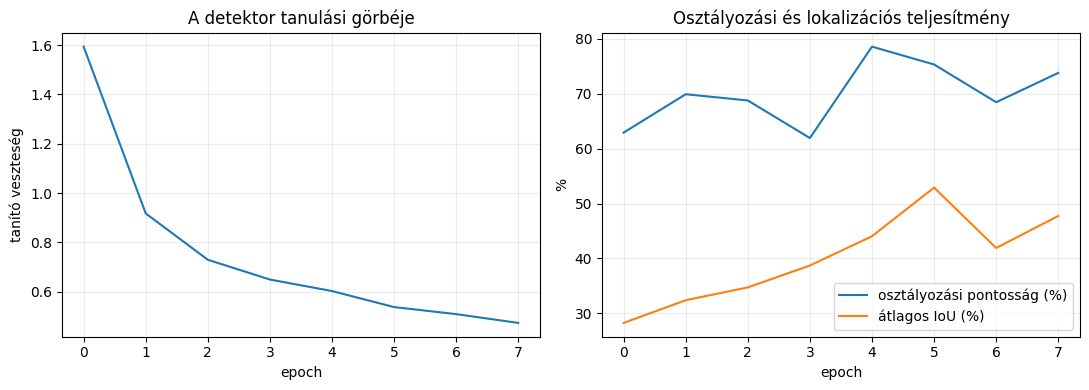

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(detector_history["loss"])
axes[0].set(xlabel="epoch", ylabel="tanító veszteség", title="A detektor tanulási görbéje")
axes[1].plot(np.array(detector_history["accuracy"]) * 100, label="osztályozási pontosság (%)")
axes[1].plot(np.array(detector_history["mean_iou"]) * 100, label="átlagos IoU (%)")
axes[1].set(xlabel="epoch", ylabel="%", title="Osztályozási és lokalizációs teljesítmény")
axes[1].legend()
for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()


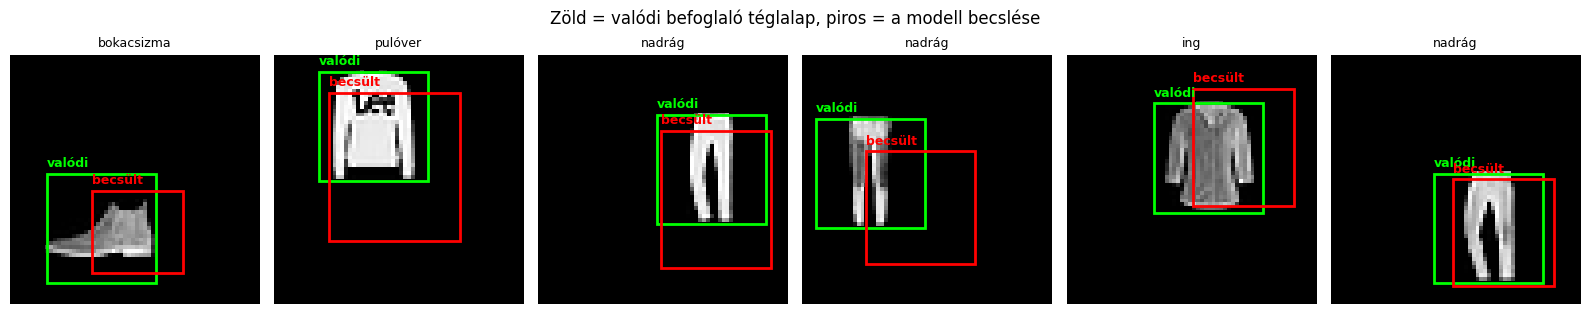

In [23]:
detector_model.eval()
fig, axes = plt.subplots(1, 6, figsize=(16, 3.2))
with torch.no_grad():
    for index, axis in enumerate(axes):
        image, label, gt_bbox = detection_test_dataset[index]
        class_logits, bbox_pred = detector_model(image.unsqueeze(0).to(device))
        predicted_label = class_logits.argmax(dim=1).item()
        predicted_bbox = bbox_pred.squeeze(0).cpu()

        draw_sample(axis, image, "", gt_bbox, color="lime", box_label="valódi")
        draw_sample(axis, image, fashion_classes[predicted_label], predicted_bbox, color="red", box_label="becsült")
plt.suptitle("Zöld = valódi befoglaló téglalap, piros = a modell becslése")
plt.tight_layout()
plt.show()


A modell a néhány epochos, kis tanítóhalmazon is megtanulja hozzávetőlegesen bekeretezni és felismerni az objektumot. Az architektúra lényege, hogy a backbone és a két fej **egyszerre**, egyetlen közös hátterjesztéssel tanul: a jellemzőknek egyszerre kell alkalmasnak lenniük az osztály felismerésére és a pozíció becslésére is.

---

# Összefoglalás

1. A teljesen összekötött réteg paraméterszáma a képmérettel négyzetesen nő, míg egy konvolúciós rétegé állandó, mert ugyanazt a kis kernelt csúsztatjuk a képen.
2. A lokális kapcsolódás és a paramegosztás miatt egy konvolúciós háló hasonló paraméterszám mellett is jobban általánosít képi adaton, mint egy teljesen összekötött háló.
3. A LeNet-5 a konvolúció → aktiváció → pooling alapmintát vezette be, amit a mai architektúrák is követnek.
4. A VGG16 mély, kis ($3\times3$) kernelekből álló blokkokra épül; nagyobb kapacitása nem mindig indokolja a nagyobb számítási igényt egy egyszerű feladaton.
5. A láncszabály miatt sok, $1$-nél kisebb deriváltú aktiváció (szigmoid, tanh) egymás után szorozva eltüntetheti a korai rétegek gradiensét.
6. A mélység növelése önmagában nem garantál jobb teljesítményt: elágazás nélküli hálóknál egy bizonyos mélység felett a tanítási hiba is romolhat (degradációs probléma).
7. A ResNet reziduális blokkja ($\mathcal{F}(\mathbf{h})+\mathbf{h}$) lehetővé teszi, hogy egy blokk csak egy maradékot tanuljon, és a gradiens szabadon átfolyjon a hálón.
8. Az objektumdetektálás egyszerre osztályozási és lokalizációs feladat; egy közös backbone-ra épülő, feladatspecifikus fejekkel már egyetlen objektumra is megvalósítható egy áttekinthető architektúra.
9. Több feladat együttes tanításakor a veszteségek súlyozása (pl. $\lambda$ a téglalap-veszteségen) szükséges, mert a két veszteség eltérő nagyságrendű lehet.
10. Az IoU (Intersection over Union) a bekeretezés pontosságának természetes mérőszáma: két téglalap átfedésének arányát fejezi ki.


# Önálló feladatok

## 1. Paraméterszám más képméreteken

Számítsd ki az `fc_first_layer_params` és `conv_layer_params` értékét egy $4000\times3000$-es (tipikus fényképfelbontású) képre. Hányszoros a különbség?

**Kapcsolódó korábbi rész:** a 6. cella definiálja a két függvényt és ábrázolja a paraméterszám növekedését.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
side = 4000  # egyszerűsítve négyzetes képet feltételezve
print(fc_first_layer_params(side))
print(conv_layer_params())
print(fc_first_layer_params(side) / conv_layer_params())
# A teljesen összekötött réteg ezen a képméreten több milliárdszor annyi paramétert igényelne.
-->


## 2. Az egyszerű CNN kapacitása

Módosítsd a `make_simple_cnn` csatornaszámait úgy, hogy a paraméterszám kb. felére csökkenjen. Romlik-e a tesztpontosság?

**Kapcsolódó korábbi rész:** a 8. cella definiálja az `make_mlp` és `make_simple_cnn` architektúrákat, a 9. cella pedig a közös tanítást és összehasonlítást végzi.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
def make_smaller_cnn():
    return nn.Sequential(
        nn.Conv2d(1, 8, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(8, 16, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Flatten(),
        nn.Linear(16 * 7 * 7, 64),
        nn.ReLU(),
        nn.Linear(64, 10),
    )

torch.manual_seed(42)
smaller_cnn = make_smaller_cnn()
print(count_parameters(smaller_cnn))
smaller_optimizer = torch.optim.SGD(smaller_cnn.parameters(), lr=0.1)
train_classifier("Kisebb CNN", smaller_cnn, smaller_optimizer, mnist_train_loader, mnist_test_loader, epochs=5)
-->


## 3. LeNet aktivációjának cseréje

Cseréld a `LeNet5` `tanh` aktivációját `ReLU`-ra. Változik-e a tanulási görbe alakja vagy a konvergencia sebessége?

**Kapcsolódó korábbi rész:** a 11-12. cella vezeti be a Fashion-MNIST-et és a `LeNet5` osztályt, a 12. cella pedig a tanítást is elvégzi.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
class LeNet5ReLU(LeNet5):
    def __init__(self, num_classes=10):
        super().__init__(num_classes)
        self.activation = torch.relu

torch.manual_seed(42)
lenet_relu = LeNet5ReLU()
lenet_relu_optimizer = torch.optim.SGD(lenet_relu.parameters(), lr=0.1, momentum=0.9)
train_classifier("LeNet-5 (ReLU)", lenet_relu, lenet_relu_optimizer, fashion_train_loader, fashion_test_loader, epochs=8)
-->


## 4. Kisebb VGG-konfiguráció

Hozz létre egy rövidebb VGG-konfigurációt (pl. csak 3 blokkal, `[64, 64, "M", 128, 128, "M", 256, 256, "M"]`), és hasonlítsd össze a paraméterszámát és tesztpontosságát a teljes VGG16-tal.

**Kapcsolódó korábbi rész:** a 14-16. cella vezeti be a `VGG16_CONFIG`-ot, a `make_vgg_feature_layers` függvényt és a tanítást.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
SHORT_VGG_CONFIG = [64, 64, "M", 128, 128, "M", 256, 256, "M"]

torch.manual_seed(42)
short_vgg = VGG16Small(input_side=32)
short_vgg.features = make_vgg_feature_layers(SHORT_VGG_CONFIG, in_channels=1)
reduced_side = 32 // (2 ** SHORT_VGG_CONFIG.count("M"))
short_vgg.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(256 * reduced_side * reduced_side, 256),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(256, 10),
)
print(count_parameters(short_vgg))
short_vgg_optimizer = torch.optim.Adam(short_vgg.parameters(), lr=1e-3)
train_classifier("Rövid VGG", short_vgg, short_vgg_optimizer, vgg_train_loader, vgg_test_loader, epochs=8)
-->


## 5. Gradiensnorma más csatornaszámmal

Futtasd újra a rétegenkénti gradiensnorma-kísérletet `channels=64` mellett. Változik-e a szigmoid és a ReLU közötti különbség mértéke?

**Kapcsolódó korábbi rész:** a 18-19. cella vezeti be az eltűnő gradienst és a `build_deep_plain_cnn`/`layerwise_gradient_norms` függvényeket.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
gradient_norms_wide = {}
for activation_name, activation_cls in [("sigmoid", nn.Sigmoid), ("ReLU", nn.ReLU)]:
    torch.manual_seed(0)
    wide_model = build_deep_plain_cnn(depth, activation_cls, channels=64).to(device)
    gradient_norms_wide[activation_name] = layerwise_gradient_norms(wide_model, sample_images, sample_labels)

for activation_name, norms in gradient_norms_wide.items():
    plt.plot(range(1, depth + 1), norms, "o-", label=activation_name)
plt.yscale("log")
plt.legend()
plt.show()
-->


## 6. Még mélyebb hálók

Egészítsd ki a `depths_in_blocks` listát egy nagyobb értékkel (pl. 25), és fuss le újra a PlainNet/ResNet összehasonlítást. Folytatódik-e a degradáció a plain hálónál?

**Kapcsolódó korábbi rész:** a 21-22. cella építi fel a `BasicBlock`/`BlockNet` osztályokat és futtatja a mélységfüggő összehasonlítást.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
extended_depths = [1, 4, 9, 16, 25]
extended_results = {}
for use_skip in [False, True]:
    variant_name = "ResNet (skip)" if use_skip else "PlainNet (skip nélkül)"
    accuracies = []
    for num_blocks in extended_depths:
        torch.manual_seed(0)
        model = BlockNet(num_blocks=num_blocks, use_skip=use_skip)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        result = train_classifier(
            f"{variant_name}, {num_blocks} blokk", model, optimizer,
            depth_train_loader, fashion_test_loader, epochs=4, verbose=False,
        )
        accuracies.append(result["accuracy"][-1])
    extended_results[variant_name] = accuracies

for variant_name, accuracies in extended_results.items():
    plt.plot(extended_depths, np.array(accuracies) * 100, "o-", label=variant_name)
plt.xlabel("blokkok száma")
plt.ylabel("tesztpontosság (%)")
plt.legend()
plt.show()
-->


## 7. A veszteségsúlyozás hatása a detektornál

Próbáld ki a `bbox_weight` paramétert 1,0 és 20,0 értékkel a `train_detector` hívásában. Hogyan változik az osztályozási pontosság és az átlagos IoU egymáshoz képest?

**Kapcsolódó korábbi rész:** a 28. cella definiálja a `box_iou` és `train_detector` függvényeket, a `bbox_weight` a két veszteség súlyozását vezérli.

Kattints duplán <b>ide</b> a megoldás megtekintéséhez.

<!--
for bbox_weight in [1.0, 20.0]:
    torch.manual_seed(42)
    trial_detector = SingleObjectDetector().to(device)
    trial_optimizer = torch.optim.Adam(trial_detector.parameters(), lr=1e-3)
    print(f"\nbbox_weight = {bbox_weight}")
    train_detector(
        trial_detector, trial_optimizer,
        detection_train_loader, detection_test_loader,
        epochs=8, bbox_weight=bbox_weight,
    )
# Kis bbox_weight mellett a lokalizáció pontatlanabb marad, túl nagy súly mellett
# az osztályozási pontosság romolhat, mert az optimalizálás a téglalap-hibára fókuszál.
-->
